In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler


pd.set_option("display.max_columns", None)

In [2]:
file_path = "household_power_consumption.txt" 

df_raw = pd.read_csv(
    file_path,
    sep=";",           
    na_values=["?"],    
    low_memory=False    
)

df_raw.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df = df_raw.copy()

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Drop rows where Datetime couldn't be parsed
df = df.dropna(subset=["Datetime"])

# Make it the index
df = df.set_index("Datetime")

df = df.drop(columns=["Date", "Time"])

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
df = df.sort_index()

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [6]:
df.isna().sum().sort_values(ascending=False)

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [7]:
df_clean = df.ffill().bfill()
df_clean.isna().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [8]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2075259.0,1.086168,1.053172,0.076,0.308,0.598,1.524,11.122
Global_reactive_power,2075259.0,0.123328,0.112514,0.000,0.048,0.100,0.194,1.390
Voltage,2075259.0,240.841608,3.235574,223.200,239.000,241.020,242.870,254.150
Global_intensity,2075259.0,4.604226,4.426775,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2075259.0,1.110995,6.115908,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2075259.0,1.287958,5.786865,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2075259.0,6.416570,8.419505,0.000,0.000,1.000,17.000,31.000


In [9]:
target_col = "Global_active_power" 
df_clean[target_col].describe()

count    2.075259e+06
mean     1.086168e+00
std      1.053172e+00
min      7.600000e-02
25%      3.080000e-01
50%      5.980000e-01
75%      1.524000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64

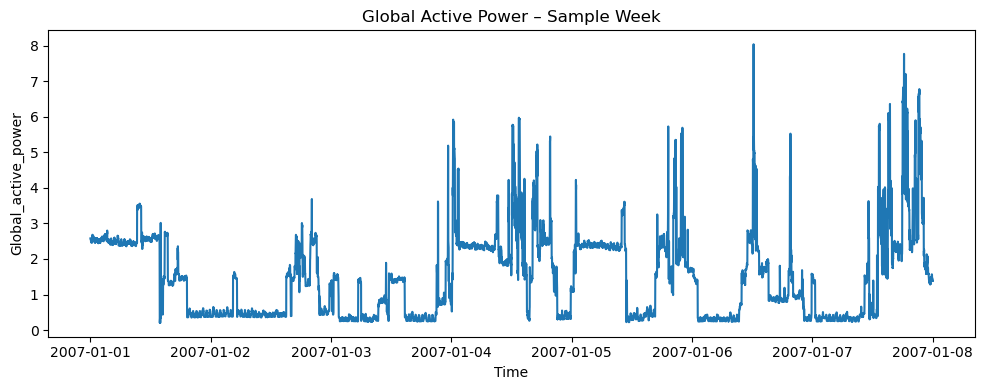

In [10]:
sample = df_clean[target_col].loc["2007-01-01":"2007-01-07"]  

plt.figure(figsize=(10, 4))
plt.plot(sample.index, sample.values)
plt.title("Global Active Power – Sample Week")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.tight_layout()
plt.show()

In [11]:
df_daily = df.resample("D").mean()
df_daily.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


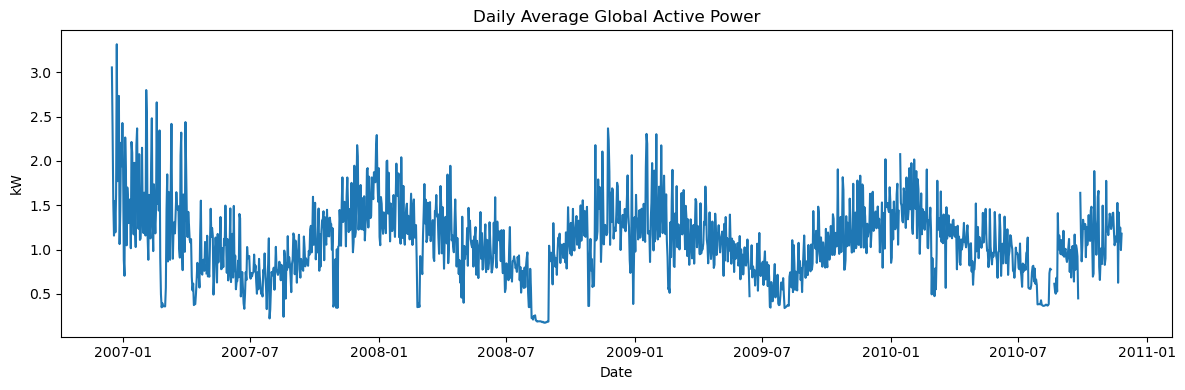

In [12]:
plt.figure(figsize=(12,4))
plt.plot(df_daily.index, df_daily["Global_active_power"])
plt.title("Daily Average Global Active Power")
plt.ylabel("kW")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [13]:
corr = df_daily.corr()

corr["Global_active_power"].sort_values(ascending=False)

Global_active_power      1.000000
Global_intensity         0.999187
Sub_metering_3           0.728800
Sub_metering_1           0.541115
Sub_metering_2           0.474655
Voltage                  0.111052
Global_reactive_power    0.039504
Name: Global_active_power, dtype: float64

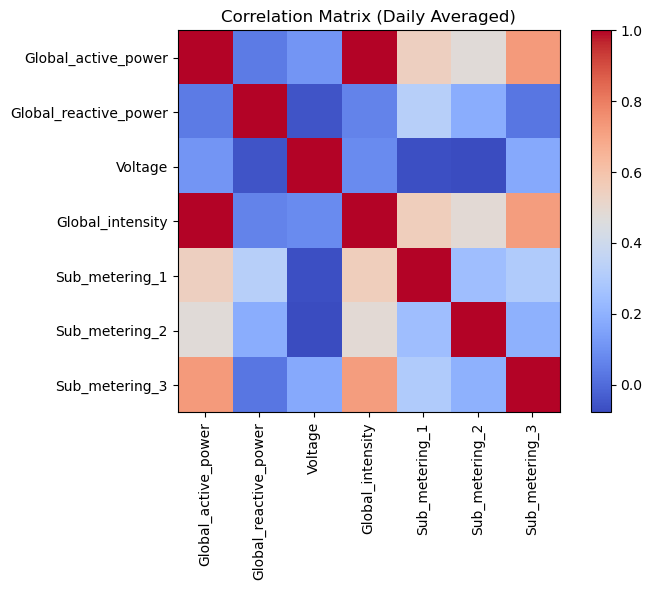

In [14]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix (Daily Averaged)")
plt.tight_layout()
plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [16]:
target_col = "Global_active_power"
y = df_daily[target_col]

In [17]:
lags = [1, 7, 30]

X_uni = pd.concat(
    [y.shift(lag).rename(f"lag_{lag}") for lag in lags],
    axis=1
)

y_uni = y.copy()  # current day target

# Drop rows with NaN created by shifting
data_uni = pd.concat([X_uni, y_uni.rename("target")], axis=1).dropna()

X_uni = data_uni[[f"lag_{lag}" for lag in lags]]
y_uni = data_uni["target"]

X_uni.head()

,lag_1,lag_7,lag_30
Datetime,,,
2007-01-15,2.090213,1.556500,3.053475
2007-01-16,1.492137,1.297954,2.354486
2007-01-17,1.171114,1.496389,1.530435
2007-01-18,1.977561,1.566107,1.157079
2007-01-19,1.264904,1.014789,1.545658


In [18]:
other_feats = ["Global_reactive_power", "Voltage",
               "Global_intensity",
               "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]

# Features at t-1 (you can add more lags later if you want)
others_t1 = df_daily[other_feats].shift(1).add_suffix("_t-1")

X_multi = pd.concat(
    [X_uni, others_t1],  # reuse lag features from above
    axis=1
)

y_multi = y_uni.copy()  # same target alignment as univariate

data_multi = pd.concat([X_multi, y_multi.rename("target")], axis=1).dropna()

X_multi = data_multi.drop(columns=["target"])
y_multi = data_multi["target"]

X_multi.head()

,lag_1,lag_7,lag_30,Global_reactive_power_t-1,Voltage_t-1,Global_intensity_t-1,Sub_metering_1_t-1,Sub_metering_2_t-1,Sub_metering_3_t-1
Datetime,,,,,,,,,
2007-01-15,2.090213,1.556500,3.053475,0.157832,238.821849,8.968311,1.234885,2.929117,9.016678
2007-01-16,1.492137,1.297954,2.354486,0.121431,241.240910,6.261528,0.763194,1.554861,10.529861
2007-01-17,1.171114,1.496389,1.530435,0.128769,241.944757,4.975972,1.432639,0.447222,4.571528
2007-01-18,1.977561,1.566107,1.157079,0.139411,241.005250,8.283889,2.430556,3.984028,11.155556
2007-01-19,1.264904,1.014789,1.545658,0.123411,240.893597,5.342500,0.000000,0.233333,9.368750


In [19]:
train_end = "2009-12-31"
test_start = "2010-01-01"

# Univariate
X_uni_train = X_uni.loc[:train_end]
y_uni_train = y_uni.loc[:train_end]

X_uni_test = X_uni.loc[test_start:]
y_uni_test = y_uni.loc[test_start:]

# Multivariate
X_multi_train = X_multi.loc[:train_end]
y_multi_train = y_multi.loc[:train_end]

X_multi_test = X_multi.loc[test_start:]
y_multi_test = y_multi.loc[test_start:]

X_uni_train.shape, X_uni_test.shape, X_multi_train.shape, X_multi_test.shape

((1074, 3), (306, 3), (1074, 9), (306, 9))

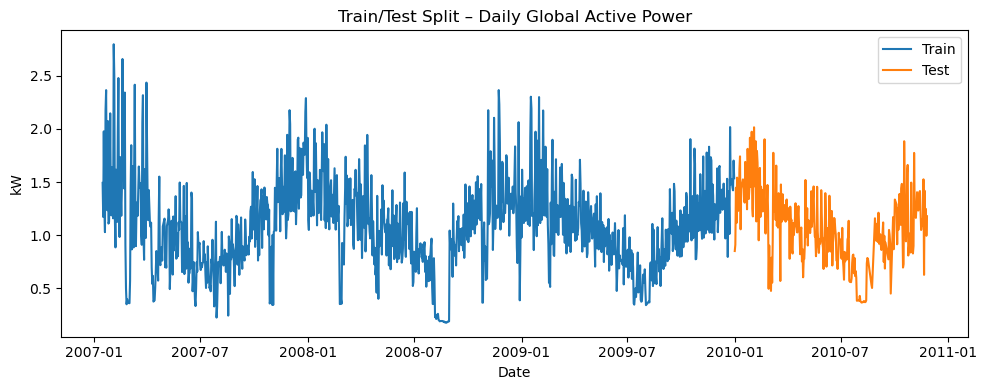

In [20]:
plt.figure(figsize=(10,4))
plt.plot(y_uni_train.index, y_uni_train, label="Train")
plt.plot(y_uni_test.index, y_uni_test, label="Test")
plt.title("Train/Test Split – Daily Global Active Power")
plt.xlabel("Date")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Univariate naive: y_hat(t) = y(t-1)
y_pred_uni_naive = y_uni.shift(1).loc[y_uni_test.index]

# Multivariate: target is the same series
y_pred_multi_naive = y_multi.shift(1).loc[y_multi_test.index]

In [22]:
rolling_mean_7 = y_uni_train.rolling(7).mean().iloc[-1]

y_pred_uni_ma7 = pd.Series(
    rolling_mean_7, index=y_uni_test.index
)

y_pred_multi_ma7 = pd.Series(
    rolling_mean_7, index=y_multi_test.index
)

In [23]:
def evaluate(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{name} → RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    return rmse, mae

# Univariate baselines
evaluate(y_uni_test, y_pred_uni_naive, "UNI — Naive")
evaluate(y_uni_test, y_pred_uni_ma7, "UNI — MA(7)")

# Multivariate baselines
evaluate(y_multi_test, y_pred_multi_naive, "MULTI — Naive")
evaluate(y_multi_test, y_pred_multi_ma7, "MULTI — MA(7)")

UNI — Naive → RMSE: 0.3032, MAE: 0.2200
UNI — MA(7) → RMSE: 0.5710, MAE: 0.4907
MULTI — Naive → RMSE: 0.3032, MAE: 0.2200
MULTI — MA(7) → RMSE: 0.5710, MAE: 0.4907


(0.570975542295482, 0.4907465814715367)

In [26]:
sc_uni = StandardScaler()
X_uni_train_scaled = sc_uni.fit_transform(X_uni_train)
X_uni_test_scaled  = sc_uni.transform(X_uni_test)

In [27]:
sc_multi = StandardScaler()
X_multi_train_scaled = sc_multi.fit_transform(X_multi_train)
X_multi_test_scaled  = sc_multi.transform(X_multi_test)

In [28]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [29]:
def reg_metrics(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{name} → RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    return rmse, mae

In [30]:
tscv = TimeSeriesSplit(n_splits=5)

In [31]:
param_grid_rbf = {
    "alpha": [0.01, 0.1, 1.0, 10.0],
    "gamma": [0.01, 0.1, 1.0, 10.0]  # gamma = 1 / (2 * lengthscale^2)
}

krr_rbf_uni = KernelRidge(kernel="rbf")

In [32]:
grid_rbf_uni = GridSearchCV(
    krr_rbf_uni,
    param_grid_rbf,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_rbf_uni.fit(X_uni_train_scaled, y_uni_train)
print("Best params (UNI RBF):", grid_rbf_uni.best_params_)

Best params (UNI RBF): {'alpha': 1.0, 'gamma': 0.01}


In [33]:
y_pred_uni_rbf = grid_rbf_uni.predict(X_uni_test_scaled)
reg_metrics(y_uni_test, y_pred_uni_rbf, "UNI — KRR RBF")

UNI — KRR RBF → RMSE: 0.2566, MAE: 0.1954


(0.2566436908400562, 0.1954082146796304)

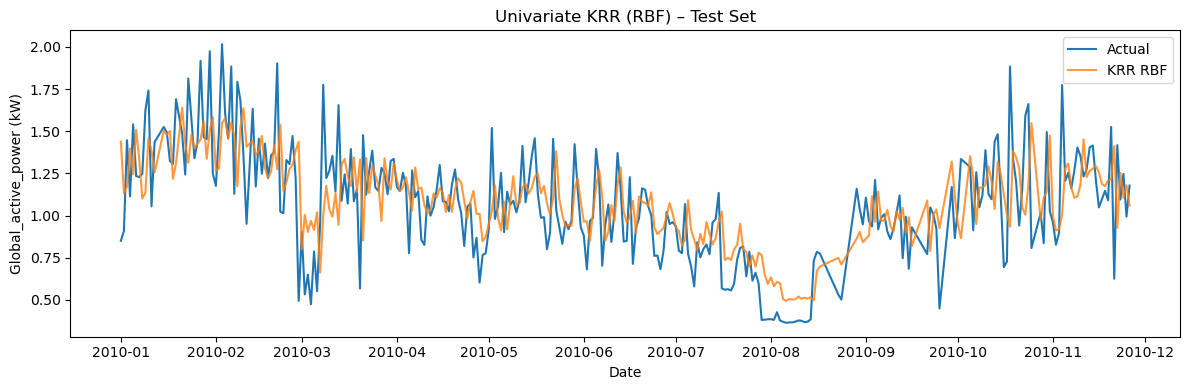

In [34]:
plt.figure(figsize=(12,4))
plt.plot(y_uni_test.index, y_uni_test, label="Actual")
plt.plot(y_uni_test.index, y_pred_uni_rbf, label="KRR RBF", alpha=0.8)
plt.title("Univariate KRR (RBF) – Test Set")
plt.xlabel("Date")
plt.ylabel("Global_active_power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
param_grid_poly = {
    "alpha": [0.01, 0.1, 1.0, 10.0],
    "degree": [2, 3, 4],
    "coef0": [0.0, 1.0, 5.0]
}

krr_poly_uni = KernelRidge(kernel="poly")

In [36]:
grid_poly_uni = GridSearchCV(
    krr_poly_uni,
    param_grid_poly,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_poly_uni.fit(X_uni_train_scaled, y_uni_train)
print("Best params (UNI Poly):", grid_poly_uni.best_params_)

Best params (UNI Poly): {'alpha': 10.0, 'coef0': 5.0, 'degree': 2}


In [37]:
y_pred_uni_poly = grid_poly_uni.predict(X_uni_test_scaled)
reg_metrics(y_uni_test, y_pred_uni_poly, "UNI — KRR Poly")

UNI — KRR Poly → RMSE: 0.2561, MAE: 0.1926


(0.2560565475394922, 0.19259891801372625)

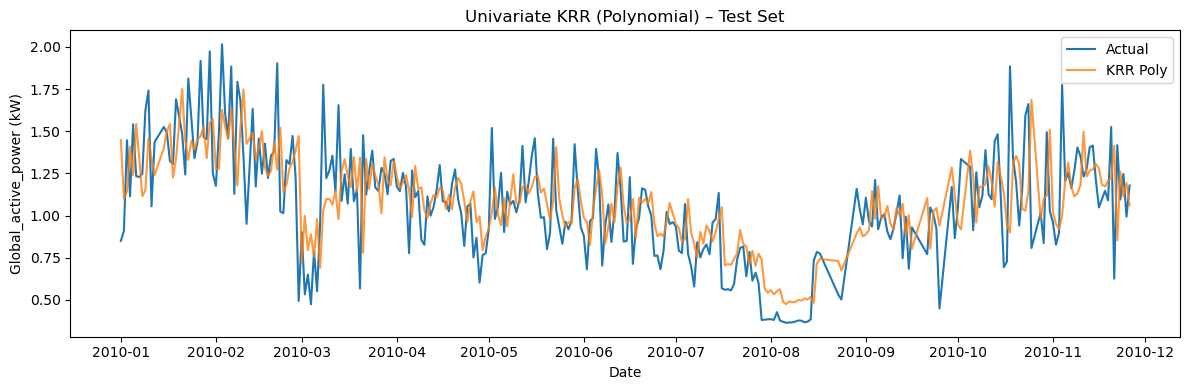

In [42]:
plt.figure(figsize=(12, 4))
plt.plot(y_uni_test.index, y_uni_test, label="Actual")
plt.plot(y_uni_test.index, y_pred_uni_poly, label="KRR Poly", alpha=0.8)
plt.title("Univariate KRR (Polynomial) – Test Set")
plt.xlabel("Date")
plt.ylabel("Global_active_power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
krr_rbf_multi = KernelRidge(kernel="rbf")

grid_rbf_multi = GridSearchCV(
    krr_rbf_multi,
    param_grid_rbf,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_rbf_multi.fit(X_multi_train_scaled, y_multi_train)
print("Best params (MULTI RBF):", grid_rbf_multi.best_params_)

Best params (MULTI RBF): {'alpha': 1.0, 'gamma': 0.01}


In [39]:
y_pred_multi_rbf = grid_rbf_multi.predict(X_multi_test_scaled)
reg_metrics(y_multi_test, y_pred_multi_rbf, "MULTI — KRR RBF")

MULTI — KRR RBF → RMSE: 0.2521, MAE: 0.1902


(0.25209704259353916, 0.19020983317861406)

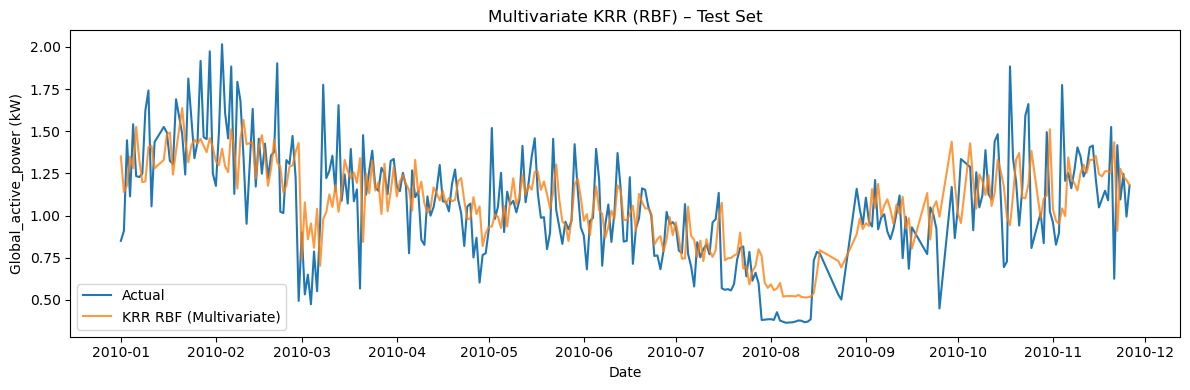

In [43]:
plt.figure(figsize=(12, 4))
plt.plot(y_multi_test.index, y_multi_test, label="Actual")
plt.plot(y_multi_test.index, y_pred_multi_rbf, label="KRR RBF (Multivariate)", alpha=0.8)
plt.title("Multivariate KRR (RBF) – Test Set")
plt.xlabel("Date")
plt.ylabel("Global_active_power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
krr_poly_multi = KernelRidge(kernel="poly")

grid_poly_multi = GridSearchCV(
    krr_poly_multi,
    param_grid_poly,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_poly_multi.fit(X_multi_train_scaled, y_multi_train)
print("Best params (MULTI Poly):", grid_poly_multi.best_params_)

Best params (MULTI Poly): {'alpha': 10.0, 'coef0': 5.0, 'degree': 2}


In [41]:
y_pred_multi_poly = grid_poly_multi.predict(X_multi_test_scaled)
reg_metrics(y_multi_test, y_pred_multi_poly, "MULTI — KRR Poly")

MULTI — KRR Poly → RMSE: 0.2508, MAE: 0.1856


(0.25077516117011767, 0.18563835917359706)

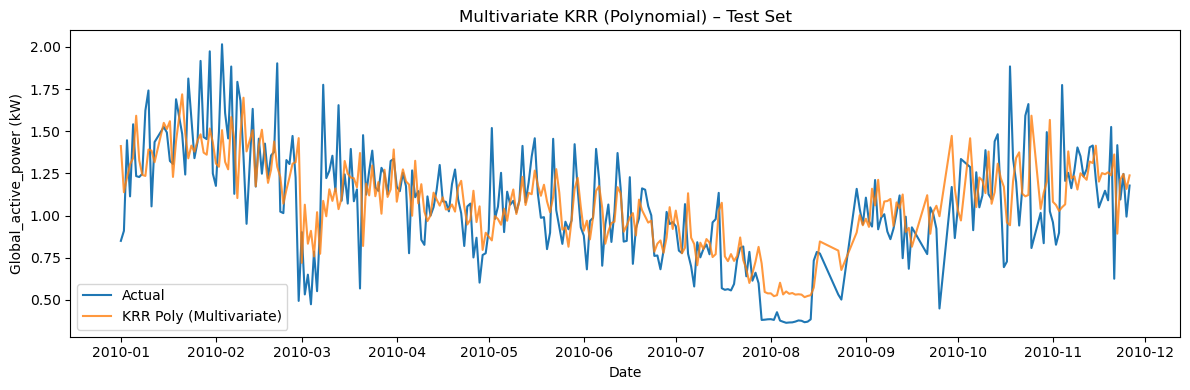

In [44]:
plt.figure(figsize=(12, 4))
plt.plot(y_multi_test.index, y_multi_test, label="Actual")
plt.plot(y_multi_test.index, y_pred_multi_poly, label="KRR Poly (Multivariate)", alpha=0.8)
plt.title("Multivariate KRR (Polynomial) – Test Set")
plt.xlabel("Date")
plt.ylabel("Global_active_power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, Matern
import numpy as np
import matplotlib.pyplot as plt

In [46]:
kernel_rbf = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

gpr_uni_rbf = GaussianProcessRegressor(
    kernel=kernel_rbf,
    alpha=0.0,
    normalize_y=True
)

gpr_uni_rbf.fit(X_uni_train_scaled, y_uni_train)
y_pred_uni_gpr_rbf = gpr_uni_rbf.predict(X_uni_test_scaled)

In [47]:
reg_metrics(y_uni_test, y_pred_uni_gpr_rbf, "UNI — GPR RBF")

UNI — GPR RBF → RMSE: 0.2539, MAE: 0.1902


(0.25391926937362874, 0.1901663771680051)

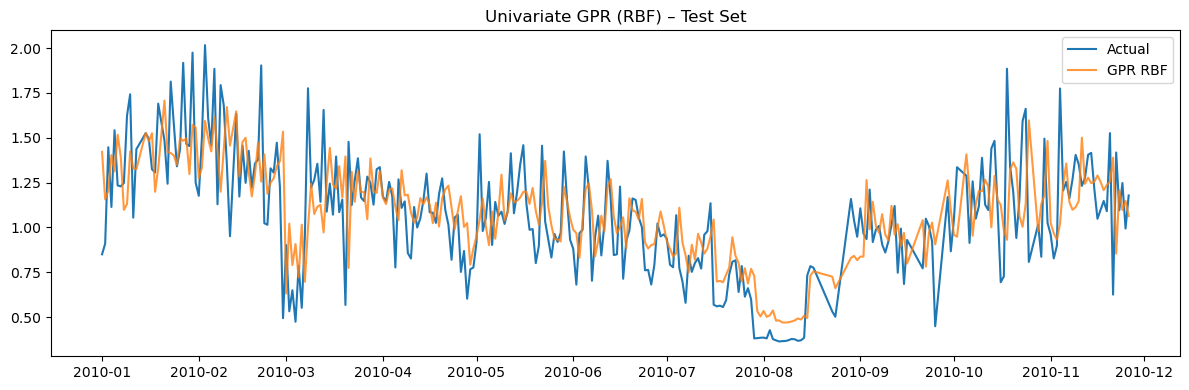

In [48]:
plt.figure(figsize=(12,4))
plt.plot(y_uni_test.index, y_uni_test, label="Actual")
plt.plot(y_uni_test.index, y_pred_uni_gpr_rbf, label="GPR RBF", alpha=0.8)
plt.title("Univariate GPR (RBF) – Test Set")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
kernel_periodic = 1.0 * ExpSineSquared(length_scale=1.0, periodicity=365) \
                  + WhiteKernel(noise_level=0.1)

gpr_uni_per = GaussianProcessRegressor(
    kernel=kernel_periodic,
    normalize_y=True,
)

gpr_uni_per.fit(X_uni_train_scaled, y_uni_train)
y_pred_uni_gpr_per = gpr_uni_per.predict(X_uni_test_scaled)

In [50]:
reg_metrics(y_uni_test, y_pred_uni_gpr_per, "UNI — GPR Periodic")

UNI — GPR Periodic → RMSE: 0.2588, MAE: 0.1970


(0.2588344704484142, 0.19702374677024906)

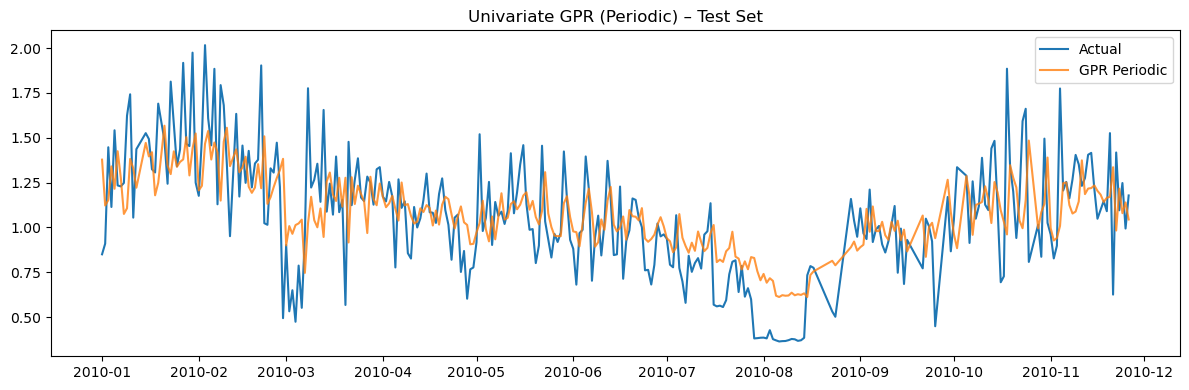

In [51]:
plt.figure(figsize=(12,4))
plt.plot(y_uni_test.index, y_uni_test, label="Actual")
plt.plot(y_uni_test.index, y_pred_uni_gpr_per, label="GPR Periodic", alpha=0.8)
plt.title("Univariate GPR (Periodic) – Test Set")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
kernel_combo = 1.0 * RBF(length_scale=1.0) \
               + 1.0 * ExpSineSquared(length_scale=1.0, periodicity=365) \
               + WhiteKernel(noise_level=0.1)

gpr_uni_combo = GaussianProcessRegressor(
    kernel=kernel_combo,
    normalize_y=True,
)

gpr_uni_combo.fit(X_uni_train_scaled, y_uni_train)
y_pred_uni_gpr_combo = gpr_uni_combo.predict(X_uni_test_scaled)

In [53]:
reg_metrics(y_uni_test, y_pred_uni_gpr_combo, "UNI — GPR (RBF + Periodic)")

UNI — GPR (RBF + Periodic) → RMSE: 0.2550, MAE: 0.1910


(0.25499674705676956, 0.1910351949972796)

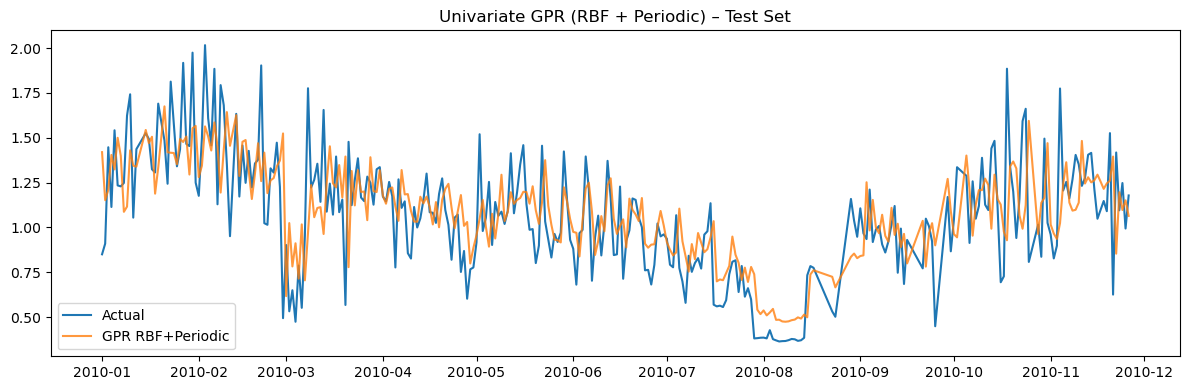

In [54]:
plt.figure(figsize=(12,4))
plt.plot(y_uni_test.index, y_uni_test, label="Actual")
plt.plot(y_uni_test.index, y_pred_uni_gpr_combo, label="GPR RBF+Periodic", alpha=0.8)
plt.title("Univariate GPR (RBF + Periodic) – Test Set")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
kernel_rbf_multi = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

gpr_multi_rbf = GaussianProcessRegressor(
    kernel=kernel_rbf_multi,
    normalize_y=True,
)

gpr_multi_rbf.fit(X_multi_train_scaled, y_multi_train)
y_pred_multi_gpr_rbf = gpr_multi_rbf.predict(X_multi_test_scaled)

In [56]:
reg_metrics(y_multi_test, y_pred_multi_gpr_rbf, "MULTI — GPR RBF")

MULTI — GPR RBF → RMSE: 0.2524, MAE: 0.1860


(0.2524145654639565, 0.18604412166688067)

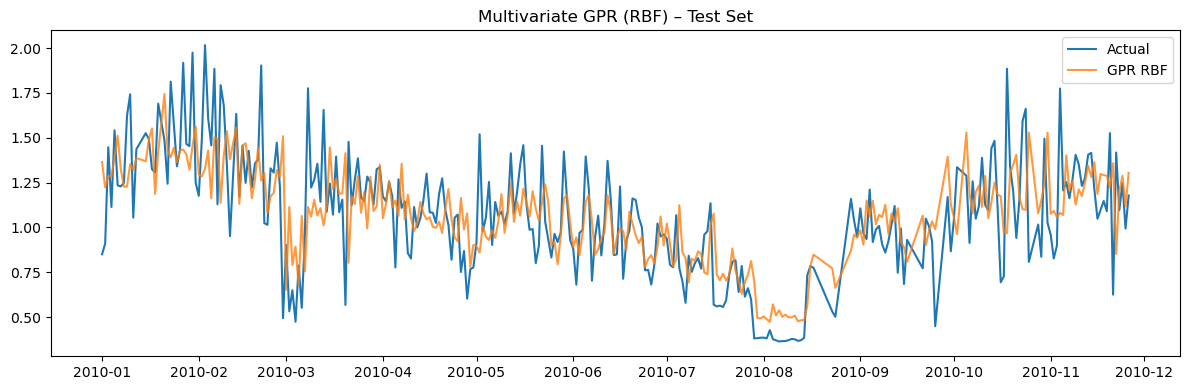

In [57]:
plt.figure(figsize=(12,4))
plt.plot(y_multi_test.index, y_multi_test, label="Actual")
plt.plot(y_multi_test.index, y_pred_multi_gpr_rbf, label="GPR RBF", alpha=0.8)
plt.title("Multivariate GPR (RBF) – Test Set")
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
kernel_matern = 1.0 * Matern(length_scale=1.0, nu=1.5) \
                + WhiteKernel(noise_level=0.1)

gpr_multi_matern = GaussianProcessRegressor(
    kernel=kernel_matern,
    normalize_y=True,
)

gpr_multi_matern.fit(X_multi_train_scaled, y_multi_train)
y_pred_multi_gpr_matern = gpr_multi_matern.predict(X_multi_test_scaled)

In [59]:
reg_metrics(y_multi_test, y_pred_multi_gpr_matern, "MULTI — GPR Matérn")

MULTI — GPR Matérn → RMSE: 0.2526, MAE: 0.1874


(0.2526397402854174, 0.18740234333407962)

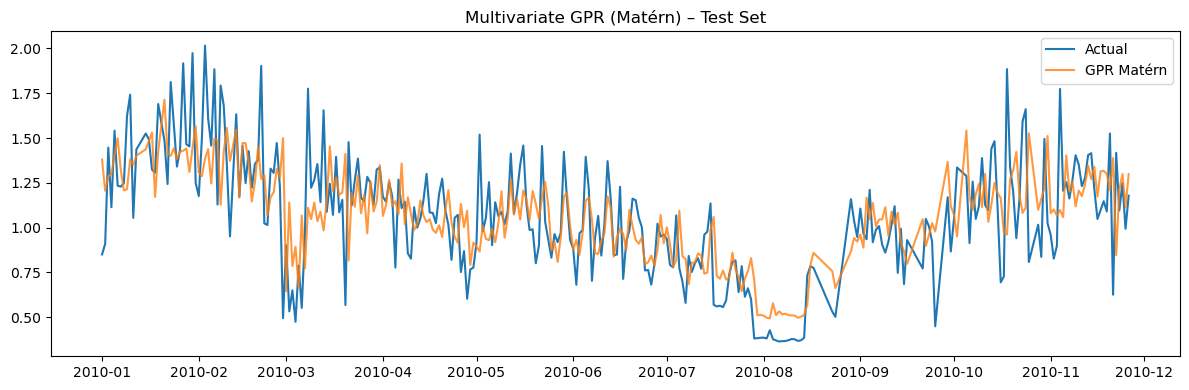

In [60]:
plt.figure(figsize=(12,4))
plt.plot(y_multi_test.index, y_multi_test, label="Actual")
plt.plot(y_multi_test.index, y_pred_multi_gpr_matern, label="GPR Matérn", alpha=0.8)
plt.title("Multivariate GPR (Matérn) – Test Set")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
results = []

def save_result(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    results.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae
    })
    print(f"{model_name} → RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    return rmse, mae

In [62]:
save_result("UNI — Naive", y_uni_test, y_pred_uni_naive)
save_result("UNI — MA(7)", y_uni_test, y_pred_uni_ma7)

save_result("UNI — KRR RBF", y_uni_test, y_pred_uni_rbf)
save_result("UNI — KRR Poly", y_uni_test, y_pred_uni_poly)

save_result("MULTI — KRR RBF", y_multi_test, y_pred_multi_rbf)
save_result("MULTI — KRR Poly", y_multi_test, y_pred_multi_poly)

save_result("UNI — GPR RBF", y_uni_test, y_pred_uni_gpr_rbf)
save_result("UNI — GPR Periodic", y_uni_test, y_pred_uni_gpr_per)
save_result("UNI — GPR RBF+Periodic", y_uni_test, y_pred_uni_gpr_combo)

save_result("MULTI — GPR RBF", y_multi_test, y_pred_multi_gpr_rbf)
save_result("MULTI — GPR Matérn", y_multi_test, y_pred_multi_gpr_matern)

UNI — Naive → RMSE: 0.3032, MAE: 0.2200
UNI — MA(7) → RMSE: 0.5710, MAE: 0.4907
UNI — KRR RBF → RMSE: 0.2566, MAE: 0.1954
UNI — KRR Poly → RMSE: 0.2561, MAE: 0.1926
MULTI — KRR RBF → RMSE: 0.2521, MAE: 0.1902
MULTI — KRR Poly → RMSE: 0.2508, MAE: 0.1856
UNI — GPR RBF → RMSE: 0.2539, MAE: 0.1902
UNI — GPR Periodic → RMSE: 0.2588, MAE: 0.1970
UNI — GPR RBF+Periodic → RMSE: 0.2550, MAE: 0.1910
MULTI — GPR RBF → RMSE: 0.2524, MAE: 0.1860
MULTI — GPR Matérn → RMSE: 0.2526, MAE: 0.1874


(0.2526397402854174, 0.18740234333407962)

In [63]:
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,MAE
0,UNI — Naive,0.303193,0.219957
1,UNI — MA(7),0.570976,0.490747
2,UNI — KRR RBF,0.256644,0.195408
3,UNI — KRR Poly,0.256057,0.192599
4,MULTI — KRR RBF,0.252097,0.190210
5,MULTI — KRR Poly,0.250775,0.185638
6,UNI — GPR RBF,0.253919,0.190166
7,UNI — GPR Periodic,0.258834,0.197024
8,UNI — GPR RBF+Periodic,0.254997,0.191035
9,MULTI — GPR RBF,0.252415,0.186044


In [64]:
results_df_sorted = results_df.sort_values("RMSE")
results_df_sorted.style.format({
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}"
})
results_df_sorted

,Model,RMSE,MAE
5,MULTI — KRR Poly,0.250775,0.185638
4,MULTI — KRR RBF,0.252097,0.190210
9,MULTI — GPR RBF,0.252415,0.186044
10,MULTI — GPR Matérn,0.252640,0.187402
6,UNI — GPR RBF,0.253919,0.190166
8,UNI — GPR RBF+Periodic,0.254997,0.191035
3,UNI — KRR Poly,0.256057,0.192599
2,UNI — KRR RBF,0.256644,0.195408
7,UNI — GPR Periodic,0.258834,0.197024
0,UNI — Naive,0.303193,0.219957


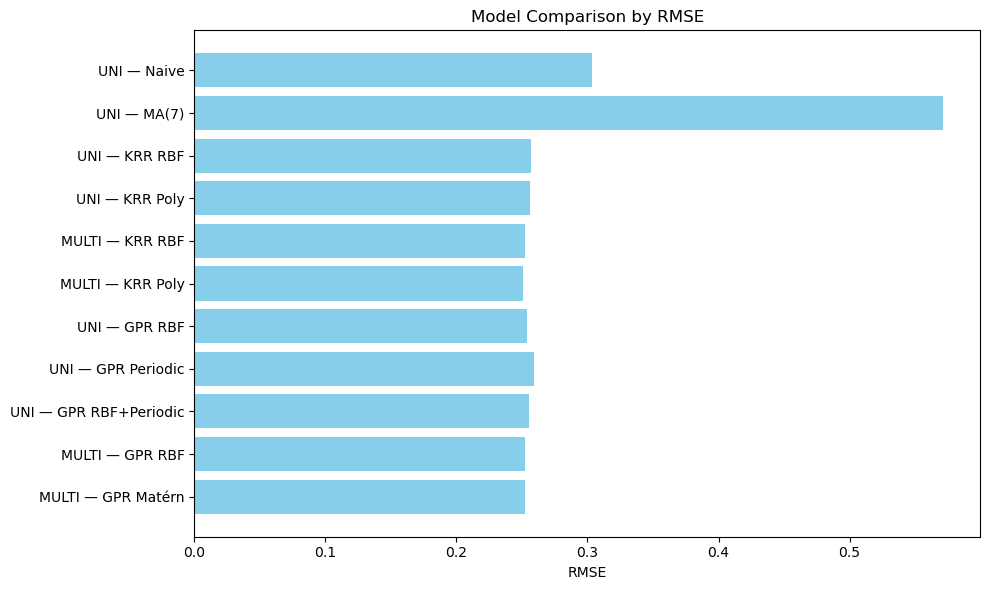

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(results_df['Model'], results_df['RMSE'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.tight_layout()
plt.show()